# Model2GDS: An Auditable Model-to-RTL Workflow for Reproducible Systolic-Array Design

**Team:** Yixuan Zhuang — School of Microelectronics, Fudan University — yixuanzhuangfudan@gmail.com. Representative: Yixuan Zhuang.

**An executable design and reproducibility notebook · Apache-2.0 · Python + SystemVerilog**

Explore a parameterized **2×2 / 4×4 / 8×8 output-stationary systolic array** through independent numerical and token-cycle models, reusable RTL, and preserved verification evidence. The systolic architecture is established practice; this notebook makes its arithmetic, cycle semantics and reproducibility inspectable and executable.

The accepted functional corpus contains **441 case/configuration executions**, with exact numerical and cycle agreement. Follow the chain **raw evidence → parser → structured result → figure**, then replay the checks from captured inputs and RTL outputs. A separate tiny-counter design demonstrates the open-source RTL-to-GDS toolchain. Notebook execution replays preserved evidence; it does not launch a new simulator or physical flow.


## 1. Start here: a portable, offline experiment

Run cells in order using Python 3.12, the tested interpreter for the pinned notebook dependencies. The first cell locates the package, verifies every bundled file and loads only preserved data. No network access, proprietary tool, Docker daemon or PDK download is required for this notebook. `python scripts/build_submission.py --verify-package` performs the same data verification from a terminal.

Commands inside original raw receipts preserve the actual historical machines. They are evidence, not local path dependencies. Fresh RTL and physical reruns are separate operations described in `README.md`.


In [1]:
from pathlib import Path
import json, sys
from html import escape
from IPython.display import display, Markdown, Image, HTML

def show_details(title, data):
    display(HTML('<details><summary>' + escape(title) + '</summary><pre>'
                 + escape(json.dumps(data, indent=2, ensure_ascii=False)) + '</pre></details>'))

start = Path.cwd().resolve()
base = next((p for p in (start, *start.parents) if (p / 'PROJECT_FREEZE.json').is_file()), None)
assert base is not None, 'Run inside the package or repository'
ROOT = base if (base / 'file_manifest.json').is_file() else base / 'ISSCC27/submitted_notebooks/Model2GDS'
assert (ROOT / 'file_manifest.json').is_file(), 'Build the verified portable candidate first'
sys.path.insert(0, str(ROOT))
from scripts.build_submission import verify_package, replay_functional
integrity = verify_package(ROOT, replay=False)
analysis = json.loads((ROOT / 'results/processed/final_analysis.json').read_text())
functional = json.loads((ROOT / 'results/processed/phase2_functional_verification.json').read_text())
frozen = json.loads((ROOT / 'PROJECT_FREEZE.json').read_text())
display(Markdown(f"**Package verification: {integrity['status']}.** Bundled source and evidence hashes were checked before loading the results."))
show_details('Package verification details', integrity)


**Package verification: PASS.** Bundled source and evidence hashes were checked before loading the results.

## 2. What the hardware computes

For `A[M,K]` and `B[K,N]`, the numerical reference computes `C=A×B`. Inputs are signed INT8; each PE sign-extends its product and accumulates in signed INT32 with modulo-2³² wrap. Reset and clear have explicit priority. This compute core deliberately omits SRAM, DMA, caches and an application processor.

One generic RTL module instantiates S×S real registered PEs, for S in {2,4,8}. A propagates right, B downward, and each accumulator remains stationary. The boundary injects lane `i`/`j` with the appropriate skew; valid/last flags travel with each token. All registers sample their old neighbors on each rising edge.

Every output tile begins with one counted clear edge. Completion comes from the active PEs' sticky result-valid flags, including the last MAC edge. Ragged tiles use an active mask. Tiles execute sequentially with no hidden inter-tile edge or overlap. The independent token model observes its own completion; a closed-form latency never tells RTL when to finish.


In [2]:
workload_table = '| Workload | M | N | K |\n|---|---:|---:|---:|\n'
for index, (M, N, K) in enumerate(frozen['workloads'], start=1):
    workload_table += f'| {index} | {M} | {N} | {K} |\n'
display(Markdown('**Pre-registered workloads.** The dimensions below are read directly from `PROJECT_FREEZE.json`; each shape is evaluated on every declared array size.'))
display(Markdown(workload_table))


**Pre-registered workloads.** The dimensions below are read directly from `PROJECT_FREEZE.json`; each shape is evaluated on every declared array size.

| Workload | M | N | K |
|---|---:|---:|---:|
| 1 | 4 | 4 | 4 |
| 2 | 8 | 8 | 8 |
| 3 | 16 | 16 | 16 |
| 4 | 32 | 32 | 32 |
| 5 | 32 | 8 | 32 |
| 6 | 32 | 32 | 8 |


Preserved directed case: D_POSITIVE
A = [[1, 2], [3, 4]] 
B = [[5, 6], [7, 8]] 
C = [[19, 22], [43, 50]]
Counted rising edges: 5


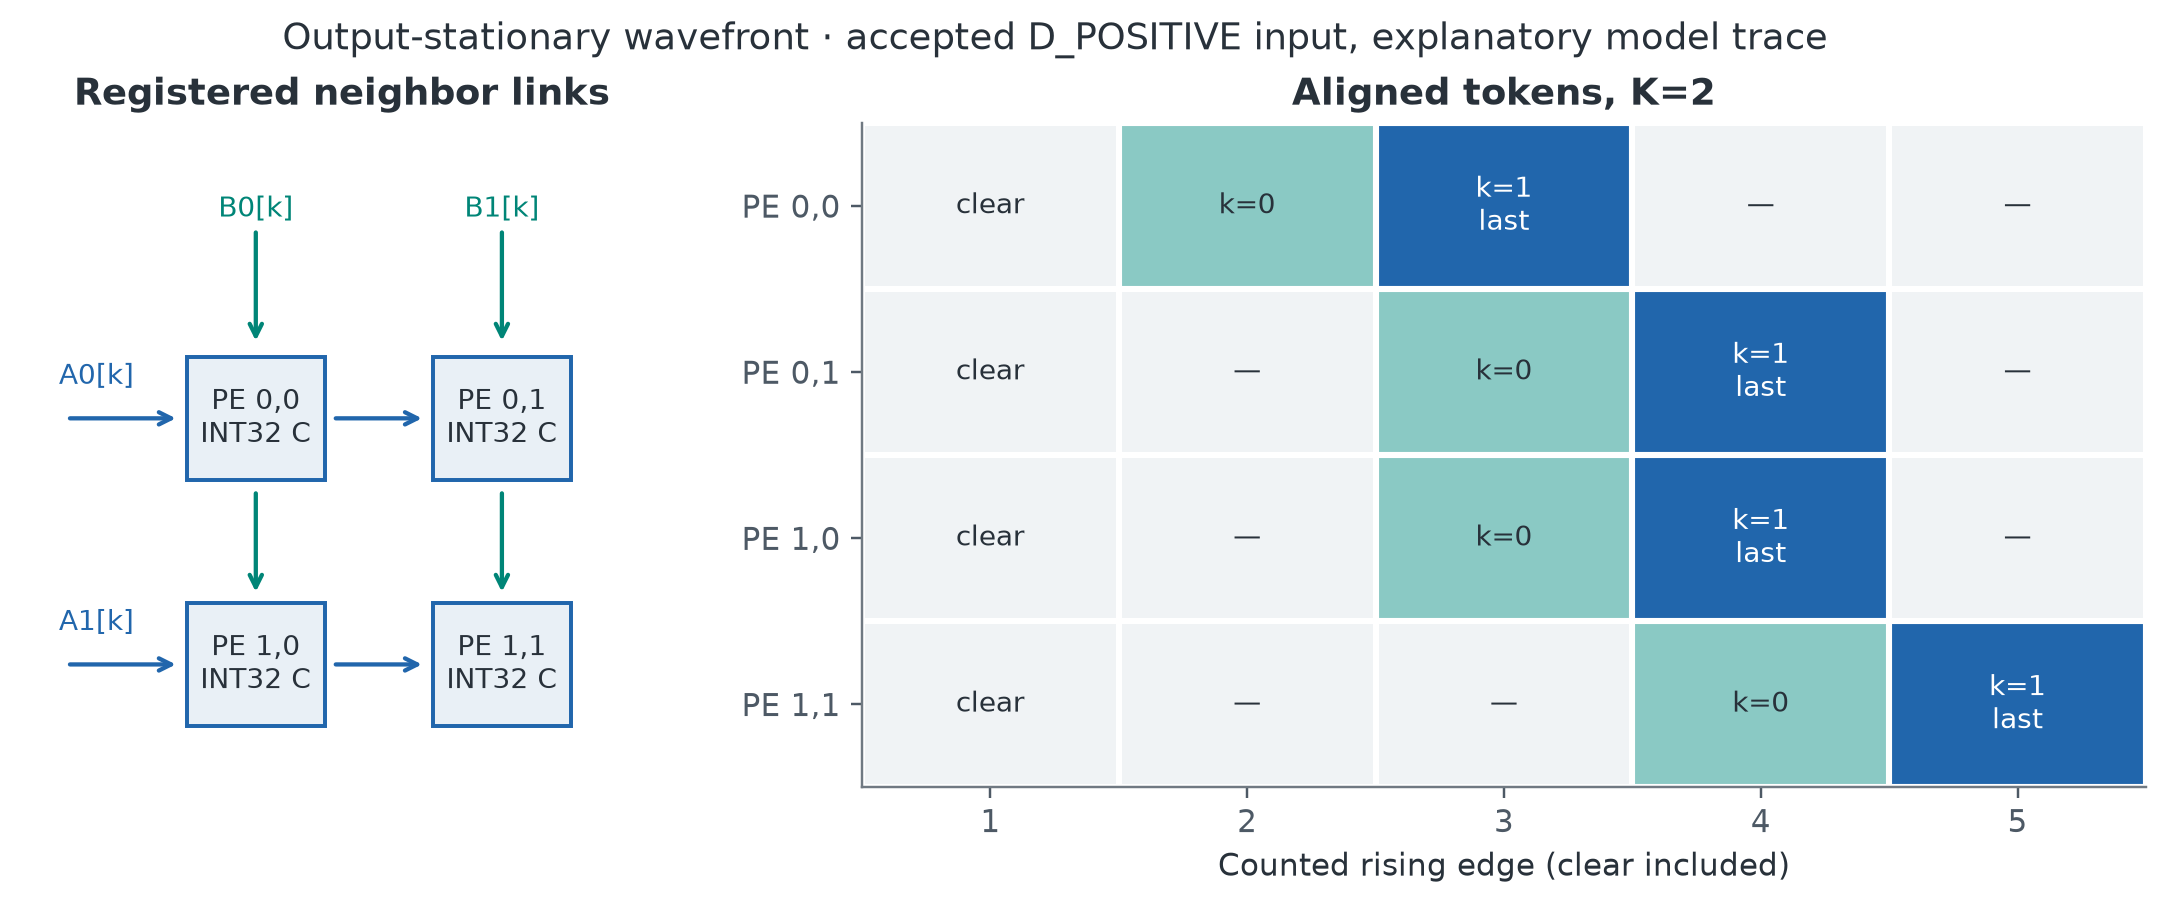

*Figure 1 — Token wavefront.* An accepted directed input illustrates registered neighbor propagation and final-token completion. The clear edge is included in the count.

In [3]:
from model.golden import gemm
from model.systolic_generic import simulate
example = analysis['wavefront_example']
A, B, S = example['A'], example['B'], example['array_size']
golden = gemm(A, B)
observed_model = simulate(A, B, S, trace=True)
assert golden == observed_model['C'] == example['C']
assert observed_model['trace'] == example['trace']
print('Preserved directed case:', example['case_id'])
print('A =', A, '\nB =', B, '\nC =', golden)
print('Counted rising edges:', observed_model['cycles'])
display(Image(filename=str(ROOT / 'figures/final/token_wavefront.png'),
              alt='Registered A and B links between four PEs, alongside their clear, MAC and final-token events on counted rising edges.'))
display(Markdown('*Figure 1 — Token wavefront.* An accepted directed input illustrates registered neighbor propagation and final-token completion. The clear edge is included in the count.'))


The trace above is regenerated from an accepted directed input. It shows token movement and completion, rather than adding a new benchmark. The executable sources are `model/golden.py`, `model/systolic_generic.py`, `rtl/gemm_pe.sv` and `rtl/systolic_array.sv`. The complete cycle and arithmetic contract is in `docs/PHASE2_FUNCTIONAL_CONTRACT.md` and `docs/PHASE1_MICROARCHITECTURE.md`.

## 3. Three independent checks of one computation

The numerical reference evaluates GEMM using explicit wrap. The token model advances PE state edge by edge. The C++/Verilator harness independently drives the RTL boundary and waits for actual RTL completion; it never receives a predicted cycle count. Deterministic randomized inputs, signed/extreme and ragged directed inputs, and the six frozen workload sanity cases are shared across configurations.

The next cell recomputes numerical outputs and the token model for every preserved case, checks the recorded RTL matrices and tile/workload counts, and validates the processed record. Captured compile/execute return codes and stream hashes must agree. A successful model replay alone is not described as a fresh simulator run.


**Offline model replay: PASS.** All **441** recorded case/configuration executions agree numerically and cycle by cycle.

| Array | Cases | Numerical pass | Cycle pass | Directed / Random / Workload |
|---|---:|---:|---:|---|
| 2×2 | 147 | 147 | 147 | 13 / 128 / 6 |
| 4×4 | 147 | 147 | 147 | 13 / 128 / 6 |
| 8×8 | 147 | 147 | 147 | 13 / 128 / 6 |


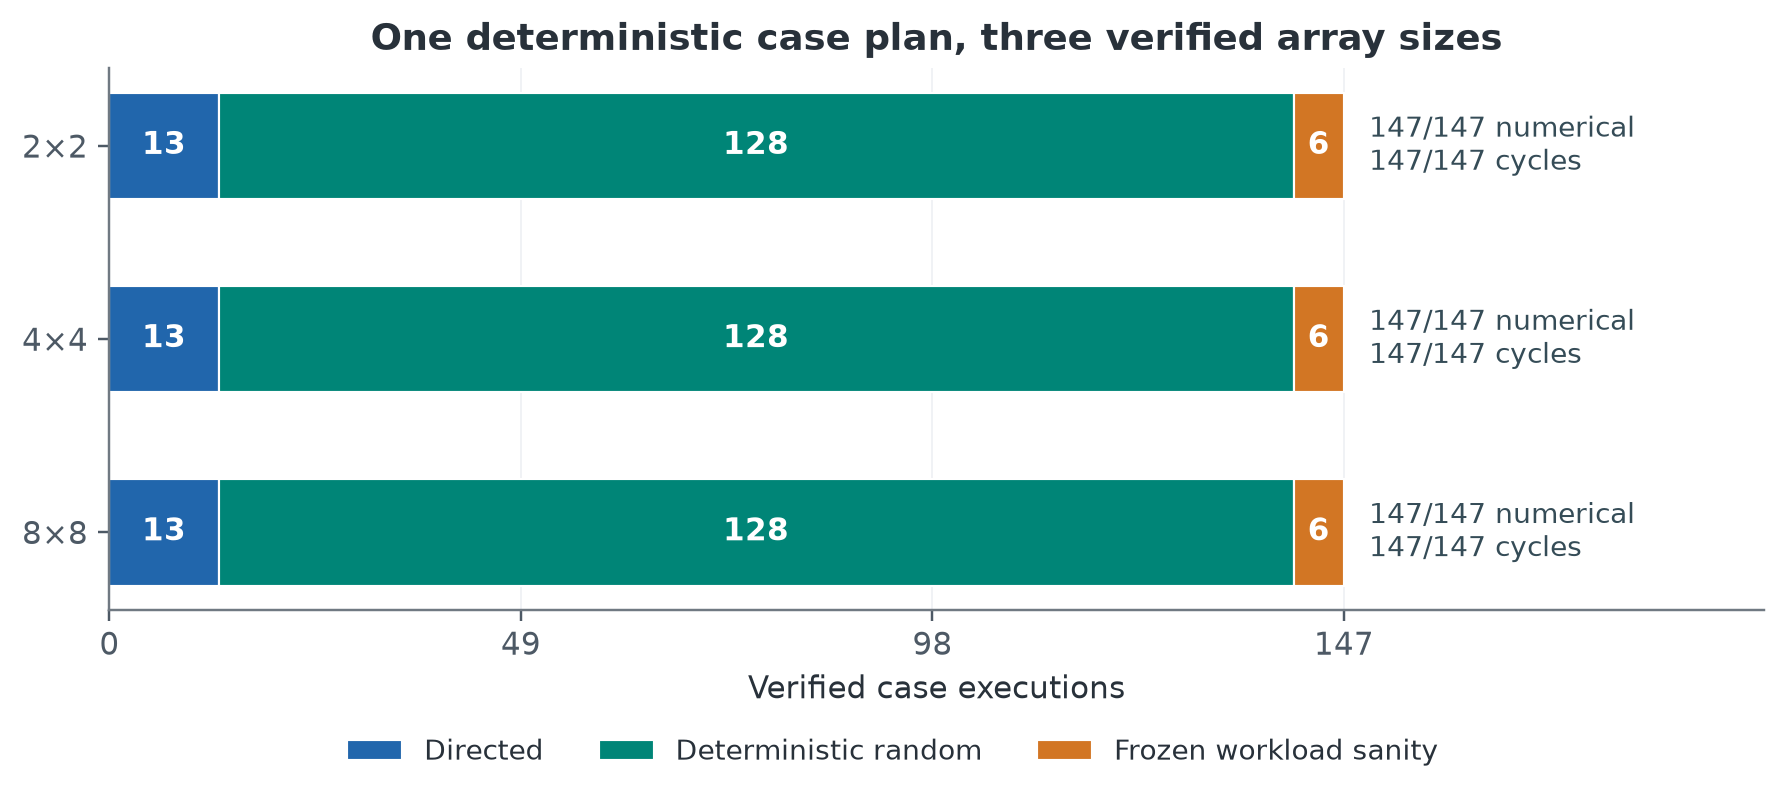

*Figure 2 — Functional coverage.* Each array uses the same preserved directed, randomized and workload-sanity corpus. Every accepted execution must agree both numerically and in cycle count.

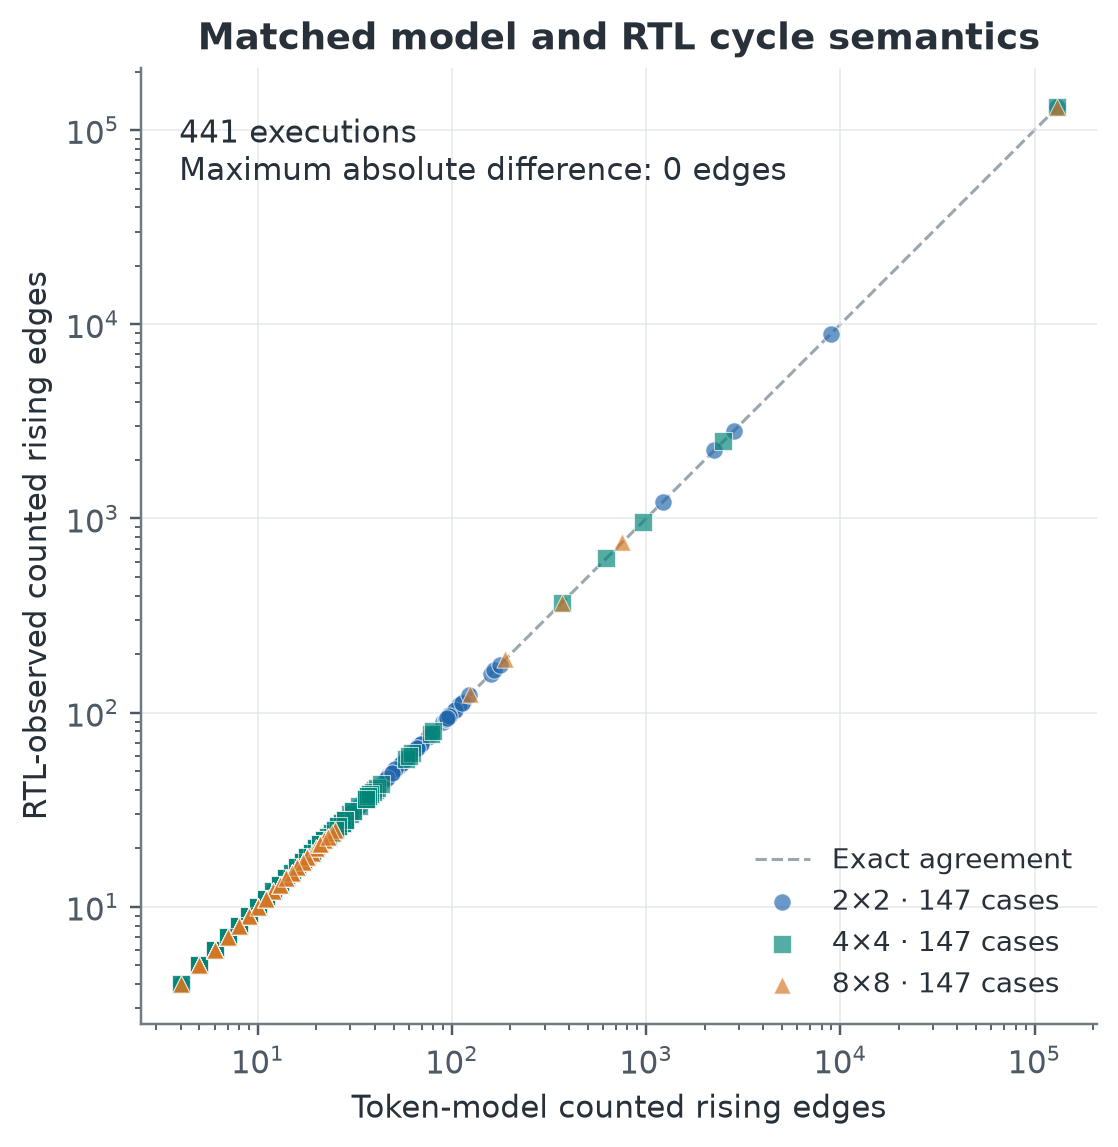

*Figure 3 — Cycle agreement.* Independent token-model counts match RTL-observed rising edges across the accepted corpus. Coincident points can overlap; this is a cycle-correctness check, not a frequency measurement.

In [4]:
replay = replay_functional(ROOT)
assert replay['total_cases'] == analysis['functional']['total_case_executions']
display(Markdown(f"**Offline model replay: {replay['status']}.** All **{replay['total_cases']}** recorded case/configuration executions agree numerically and cycle by cycle."))
show_details('Model replay details', replay)
rows = analysis['functional']['coverage']
table = '| Array | Cases | Numerical pass | Cycle pass | Directed / Random / Workload |\n|---|---:|---:|---:|---|\n'
for row in rows:
    categories = row['category_counts']
    table += f"| {row['array_size']}×{row['array_size']} | {row['case_count']} | {row['numerical_passed']} | {row['cycle_passed']} | {categories['directed']} / {categories['randomized']} / {categories['frozen_workload_sanity']} |\n"
display(Markdown(table))
display(Image(filename=str(ROOT / 'figures/final/functional_coverage.png'),
              alt='Directed, deterministic randomized and frozen-workload cases for each array size, with exact numerical and cycle matches.'))
display(Markdown('*Figure 2 — Functional coverage.* Each array uses the same preserved directed, randomized and workload-sanity corpus. Every accepted execution must agree both numerically and in cycle count.'))
display(Image(filename=str(ROOT / 'figures/final/cycle_agreement.png'),
              alt='Token-model cycles plotted against RTL-observed cycles; the accepted executions lie on the exact-agreement line.'))
display(Markdown('*Figure 3 — Cycle agreement.* Independent token-model counts match RTL-observed rising edges across the accepted corpus. Coincident points can overlap; this is a cycle-correctness check, not a frequency measurement.'))


Each point is a case/configuration observation, not an independently sampled chip. Agreement covers the tested schedule and input corpus; it is not a formal proof of all possible inputs. Directed PE tests separately exercise wrap, reset, clear, bubbles and final-token behavior. The preserved simulator version and command records are bundled alongside the raw outputs.

## 4. A real open-source RTL-to-GDS toolchain

Before the accelerator work, a tiny counter proved the complete simulation → Yosys synthesis → OpenLane/OpenROAD implementation → post-route STA → GDS chain. It used the same pinned open-source technology stack. Its layout is a **counter layout**, never an accelerator result. The package includes the raw logs, selected reports, final GDS and the original parser; the integrity cell reruns that parser without invoking any EDA tool.


In [5]:
counter = json.loads((ROOT / 'results/processed/phase0_metrics.json').read_text())
lock = json.loads((ROOT / 'environment/toolchain.lock.json').read_text())
assert counter['pass'] and counter['physical_flow']['post_route_timing']['stage'] == 'OpenROAD.STAPostPNR'
proof = {'design': counter['design'], 'run_id': counter['run_id'],
         'simulation': counter['simulation']['pass'], 'synthesis': counter['synthesis']['pass'],
         'physical_implementation': counter['physical_flow']['pass'],
         'post_route_stage': counter['physical_flow']['post_route_timing']['stage'],
         'gds': counter['physical_flow']['gds'],
         'pdk': lock['pdk']['name'], 'library': lock['standard_cell_library']['name']}
display(Markdown(f"**Tiny-counter toolchain: PASS.** `{proof['design']}` completed simulation, synthesis, physical implementation, post-route timing and GDS generation using `{proof['pdk']}` / `{proof['library']}`."))
show_details('Counter tools, run and artifact identities', proof)


**Tiny-counter toolchain: PASS.** `phase0_counter` completed simulation, synthesis, physical implementation, post-route timing and GDS generation using `sky130A` / `sky130_fd_sc_hd`.

## 5. What physical qualification taught us

The model-to-RTL workflow is verified, while accelerator physical qualification remains incomplete. A complete qualified set of implementations is needed to compare performance across array sizes. This notebook therefore makes no claim about whether cycle-based configuration choices survive post-route timing.

Completing a route or writing a GDS file is not enough. Mapped compute state must be retained, routing and enabled signoff checks must pass, and the timing query must refer to the same routed artifacts. Historical work exposed both evidence-tooling defects and antenna signoff failures. Those classes are kept separate: repairing a parser does not repair a circuit, and an unsuccessful recipe does not establish universal design infeasibility.

Rejected area, slack, frequency and GDS characteristics are excluded from scientific comparison. No accelerator scaling plot, hardware winner or ranking-disagreement claim is produced.


In [6]:
assert analysis['analysis_mode'] != 'PRIMARY_RESEARCH'
assert analysis['scientific_analysis'] is None
assert analysis['rejected_physical_performance_used'] is False
show_details('Comparative-analysis eligibility record', analysis['scientific_analysis_unavailable_reasons'])


In [7]:
history = analysis.get('physical_attempt_history')
if history is not None:
    heading = 'Physical qualification complete' if history['pass'] else 'Physical qualification incomplete'
    display(Markdown('**' + heading + '.**'))
    attempt_record = json.loads((ROOT / 'support/physical_attempt_history.json').read_text())
    attempt_table = '| Array | Physical qualification |\n|---|---|\n'
    for cfg in attempt_record['configurations']:
        if cfg['status'] == 'PASS':
            outcome = 'Final implementation qualified'
        elif cfg['status'] == 'NOT_RUN':
            outcome = 'Not run after the preceding qualification stop'
        elif 'antenna__violating' in (cfg['error'] or ''):
            outcome = 'Did not pass final antenna signoff'
        else:
            outcome = 'Not qualified for comparative analysis'
        attempt_table += f"| {cfg['array_size']}×{cfg['array_size']} | {outcome} |\n"
    display(Markdown(attempt_table))
    if history['pass']:
        display(Markdown('Only the complete qualified family supplies the comparison. Earlier partial results are excluded.'))
    else:
        display(Markdown('Incomplete physical families are excluded from scientific comparison, including performance and ranking claims. Earlier partial results are excluded.'))
    show_details('Physical qualification provenance: raw outcomes, errors and selection history', attempt_record)
    display(Markdown('The underlying records are preserved in `support/physical_attempt_history.json`; no rejected physical performance is presented.'))


**Physical qualification incomplete.**

| Array | Physical qualification |
|---|---|
| 2×2 | Final implementation qualified |
| 4×4 | Did not pass final antenna signoff |
| 8×8 | Not run after the preceding qualification stop |


Incomplete physical families are excluded from scientific comparison, including performance and ranking claims. Earlier partial results are excluded.

The underlying records are preserved in `support/physical_attempt_history.json`; no rejected physical performance is presented.

### Actual layout illustration

The overview below is drawn only from the accepted tiny-counter GDS. It is a toolchain illustration, not an accelerator implementation result.

This reproducible view selects top-cell polygons and paths on GDS layers 67–72, datatype 20, with micrometre coordinates. Reference-cell geometry and text labels are omitted; large boundary polygons are outlined. It is a selected routing overview, not a transistor-detail rendering or an additional signoff check. The same selection is used for every displayed array. Exact GDS identities follow the image.


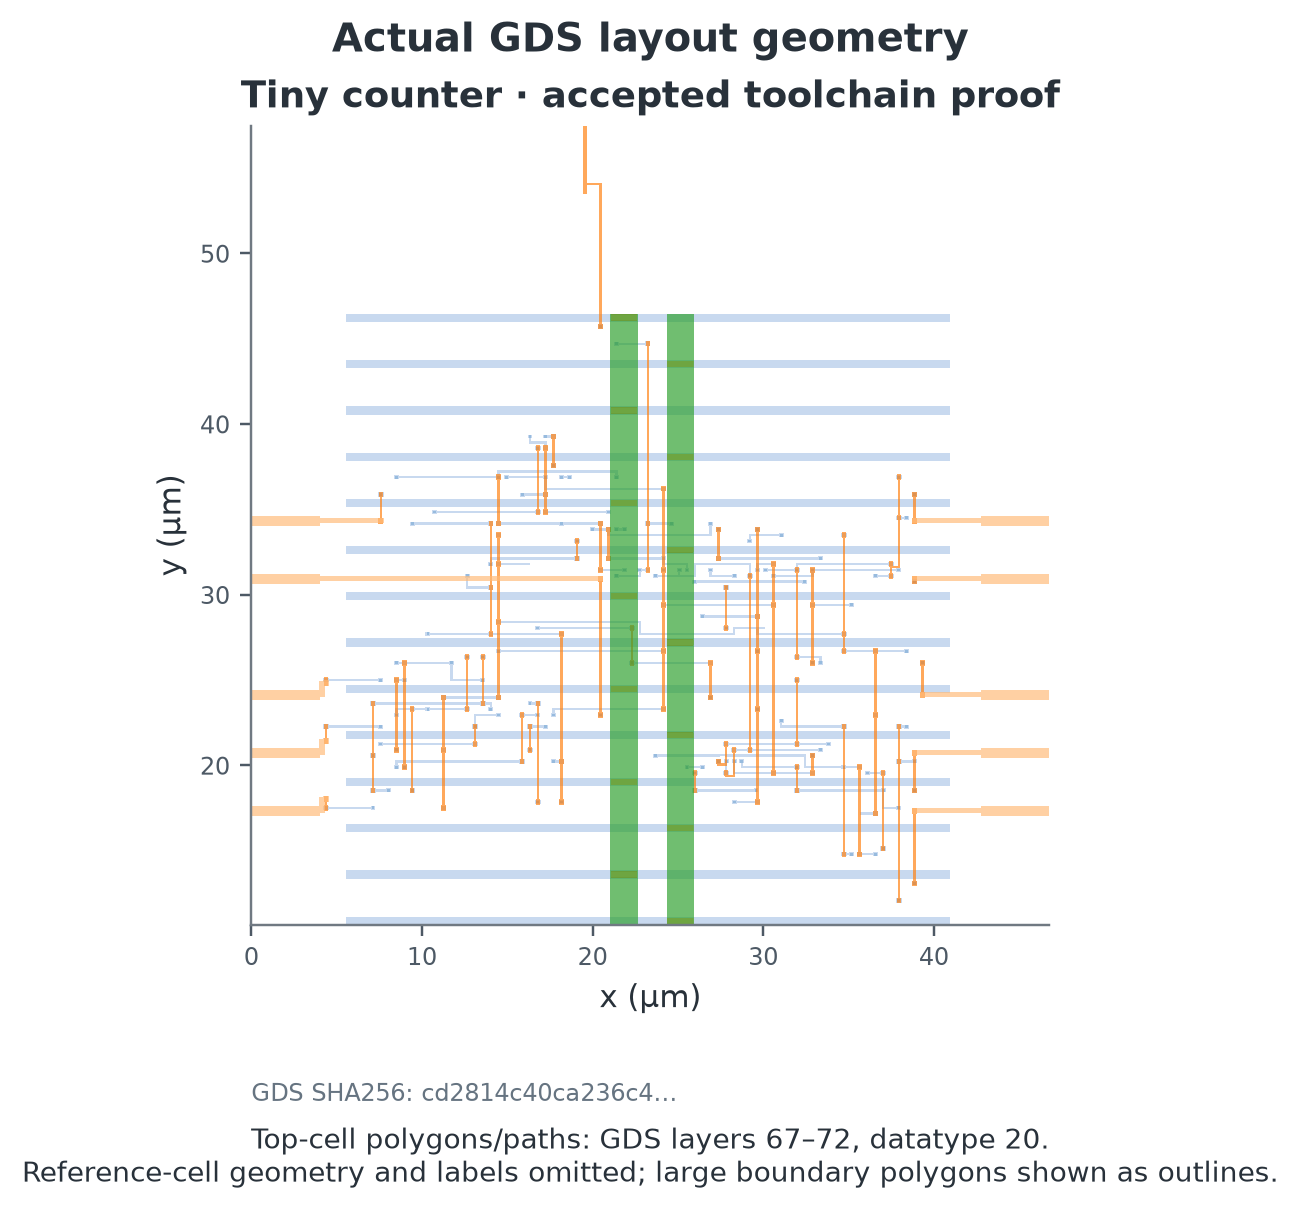

*Figure 4 — Tiny-counter toolchain proof.* This is the accepted counter GDS, not a GEMM accelerator layout. The selected routing view demonstrates the open-source RTL-to-GDS path; it adds no accelerator physical result.

In [8]:
display(Image(filename=str(ROOT / 'figures/final/layout_overview.png'), alt='Selected routing geometry from the accepted tiny-counter GDS: an open-source RTL-to-GDS toolchain proof, not the GEMM accelerator layout.'))
display(Markdown('*Figure 4 — Tiny-counter toolchain proof.* This is the accepted counter GDS, not a GEMM accelerator layout. The selected routing view demonstrates the open-source RTL-to-GDS path; it adds no accelerator physical result.'))
show_details('Layout file identities', analysis['layout_sources'])


## What this experiment establishes

### 441/441 exact agreement

Across 2×2, 4×4 and 8×8 configurations, the independent numerical model, token-cycle model and recorded RTL observations agree on every accepted case: exact numerical outputs and exact cycle counts.

### Cycle semantics are executable, not assumed

The harness observes completion from the RTL's result-valid behavior and counts simulated clock edges. A closed-form latency predictor does not supply the observed completion time.

### Evidence levels remain separate

Functional correctness, successful tool execution, generated physical artifacts and qualified physical evidence answer different questions. The accepted functional result stands on its own; the incomplete accelerator physical family supports no comparative performance or ranking claim.


## 6. Reproduce and extend responsibly

1. Create a Python environment and install `requirements.txt`.
2. Run `python scripts/build_submission.py --verify-package` from this directory. This verifies bundled hashes, reparses the counter evidence, regenerates GEMM/token results and checks captured RTL observations.
3. Run `python scripts/reproduce_figures.py --root . --portable --check` to verify figure regeneration, then execute this notebook top to bottom.

The package supports offline replay of the recorded observations. Optional fresh tool runs are described in `REBUILD.md`; the development repository retains the complete run history and qualification records.

Boundaries: idealized streaming compute core; no external-memory system, application demonstration, power or energy estimate. Verification coverage is finite. A single PDK/library and fixed backend cannot establish behavior across technologies or process variation. Agent assistance was used for engineering, tests and explanation; humans remain responsible for claims, provenance, licensing and authorship.

## References and license

- [ISSCC 2027 Code-a-Chip official repository](https://github.com/sscs-ose/sscs-ose-code-a-chip.github.io/blob/a502a6ba01260d3492df9137dddae0bb5fabeb3c/README.md): current notebook, license, project-directory and reproduction requirements. The package preserves dated rule metadata in `support/official_rules.json`; its linked older application guide is disclosed separately.
- [OpenLane 2 documentation](https://openlane2.readthedocs.io/en/stable/): reproducible RTL-to-GDS flow and Classic steps.
- [Yosys documentation](https://yosyshq.readthedocs.io/projects/yosys/en/latest/): RTL synthesis.
- [OpenROAD](https://github.com/The-OpenROAD-Project/OpenROAD) and [OpenSTA](https://github.com/The-OpenROAD-Project/OpenSTA): physical implementation and static timing.
- [SKY130 PDK documentation](https://skywater-pdk.readthedocs.io/en/main/): open technology and standard-cell context.
- [Verilator documentation](https://verilator.org/guide/latest/): compiled RTL simulation.

Project source is licensed under Apache-2.0; see `LICENSE`. Bundled GDS contains upstream standard-cell geometry; its attribution and license copies are in `NOTICE` and `third_party/`. Third-party tools/PDKs retain their own licenses. No external notebook was copied into this notebook. `REFERENCES.md` distinguishes external tools from original project material.
